This project follows the following pipeline: 
1. EDA: exploring the train.csv dataset 
2. Training three different models on the dataset with only essential preprocessing steps (proprecced only using TF-IDF, nothing else is applied), so that I could focus only on the effect of the classifier and choose the best model among those three as the baseline for preprocessing steps later. 
3. Preprocessing: After choosing the best model, we test different preprocessing methods. This way we can see any change in performance that comes from preprocessing not from the model, and select the best preprocessing pipeline. We test the following components:
    - Tokenization and basic cleaning: converting all text to lowercase, removing HTML tags and ther unnecessary symbols, working with negations (changing “can’t” to “can not”)
    - Stop-word removal: removing unnesecary words like articles, prepositions, etc, but keepig the negations like "no" and "not"
    - Comparing Stemming vs. lemmatization: comparing these tw and choosing the best one for our project 
    - Comparing vectorization methods: testing and comparing TF-IDF, CountVectorizer and 
HashingVectorizer. 
4. Model tuning: applying gridserachCV to tune hyperarameters of the best pipeline and model. 



In [25]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kanykeimairambekova/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kanykeimairambekova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kanykeimairambekova/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [49]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.svm import LinearSVC
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


**Step 1: EDA**

In [27]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

In [5]:
train = pd.read_csv(DATA_DIR / "train.csv")
print("train:", train.shape)
print("train columns:", train.columns.tolist())
print("\ntrain sentiment value counts:\n", train["sentiment"].value_counts(dropna=False))
print("\nmissing in train:\n", train.isna().mean().sort_values(ascending=False).head(10))

train: (40000, 2)
train columns: ['review', 'sentiment']

train sentiment value counts:
 sentiment
positive    20000
negative    20000
Name: count, dtype: int64

missing in train:
 review       0.0
sentiment    0.0
dtype: float64


In [6]:
test = pd.read_csv(DATA_DIR / "inference.csv")
print("test columns:", test.columns.tolist())
print("inference shae:", test.shape)

test columns: ['review', 'sentiment']
inference shae: (10000, 2)


In [7]:
train["review_length"] = train["review"].str.len()
print(train["review_length"].describe())


count    40000.000000
mean      1310.549450
std        987.955229
min         41.000000
25%        699.000000
50%        971.000000
75%       1595.000000
max      13704.000000
Name: review_length, dtype: float64


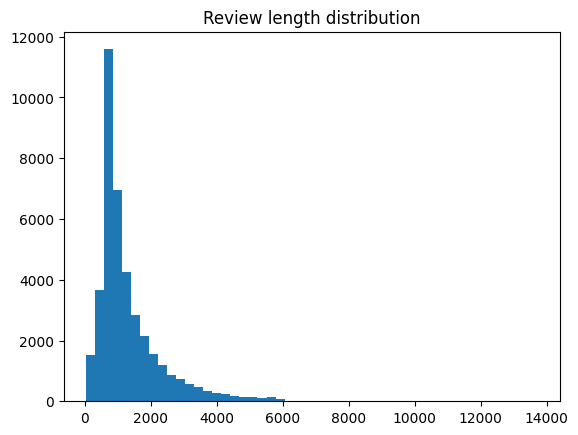

In [8]:
plt.hist(train["review_length"], bins=50)
plt.title("Review length distribution")
plt.show()

In [9]:
# average length per class
train["review_length"] = train["review"].str.len()
avg_length = train.groupby("sentiment")["review_length"].mean()
print("Average review length by sentiment:\n")
print(avg_length)

Average review length by sentiment:

sentiment
negative    1298.1433
positive    1322.9556
Name: review_length, dtype: float64


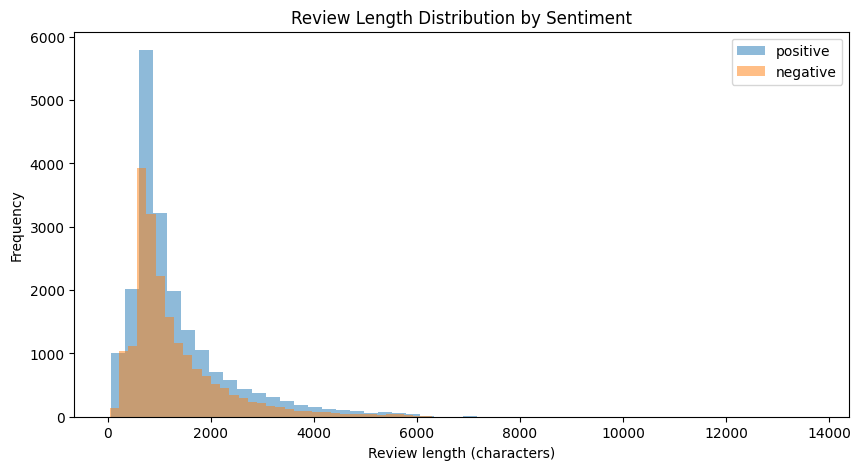

In [10]:
plt.figure(figsize=(10,5))
for label in train["sentiment"].unique():
    subset = train[train["sentiment"] == label]
    plt.hist(subset["review_length"], bins=50, alpha=0.5, label=label)
plt.legend()
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Review length (characters)")
plt.ylabel("Frequency")
plt.show()

In [89]:
print("\nSample Positive Reviews\n")
for text in train[train["sentiment"] == "positive"]["review"].sample(3, random_state=42):
    print(text[:500])  
    print("\n" + "-"*80 + "\n")

print("\nSample Negative Reviews\n")
for text in train[train["sentiment"] == "negative"]["review"].sample(3, random_state=42):
    print(text[:500])
    print("\n" + "-"*80 + "\n")


Sample Positive Reviews

Meatballs works its way into conversations, like no other movie. Especially during Summer. Whether it's the song about the CITs (Counselors In Training) or the cut-downs or the inspirational Rudy the Rabbit or It Just Doesn't Matter speech...it pops up! Poor Mickey/Morty, who knows where he'd wake up next!?! Such a great snapshot of the seventies and a cultural icon for my generation of those who understand that non-PC is really funny, no matter who you are! Wheels and Spaz are favorites, as is 

--------------------------------------------------------------------------------

I experienced Nightbreed for the first time on television a year ago and i was pleasantly surprised with the results.<br /><br />Clive Barker is said to have revitalised horror with Hellraiser but this is a film that effectively stalled his cinema career somewhat. What an unfortunate thing to happen because, like the inhabitants of Midian, this film seems to be misunderstood.<br /><br />

**EDA INSIGHTS:** 

From EDA, we see several points:
1. Class is balanced in the dataset. So, accuracy can go as the main performance metric. Since it is not a clinical domain problem, there is no need to focus on one class more that on another, so we can just look overall a F1-score instead of looking at preision or recall separatively. Thus, accuracy will be our main metric, while F1 score will be secondary. 
2. There are no missing values in the train dataset, so no need for imputation logic.
3. From the review length discribution analysis, we can see that these are full movie reviews. Also, there is not really a big difference in terms of the length between positive and negative reviews, meaning that Length is not a strong discriminative feature. 
4. We also have a high variance in document length. Sparse vectorization methods like TF-IDF can handle this.


**Step 2: Model Comparison, choosing the best model**

All models were trained and evaluated on the same train–validation split, and accuracy will be the main metric for comparison. The models are:
- Logistic Regression
- Linear SVC
- Multinomial Naive Bayes


In [18]:
X = train["review"].astype(str)
y = train["sentiment"].map({"negative": 0, "positive": 1})
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=200000
)

In [20]:
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(),
    "Multinomial NB": MultinomialNB(),}

results = {}
for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", tfidf),
        ("clf", clf)])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

print("\nSummary:", results)

LogReg accuracy: 0.9008
LinearSVC accuracy: 0.9164
Multinomial NB accuracy: 0.8895

Summary: {'LogReg': 0.90075, 'LinearSVC': 0.916375, 'Multinomial NB': 0.8895}


As LinearSVC has the higest accuracy, we will use it from no on.

**Step 2: Preprocessing**

For the preprocessing part, we tried the following things: 
1. Tokenization done inside the pipeline of TF-IDF
2. Stop-words filtering. At this point, we will remove stopwords with the help of standard stopwords list. However, we keep negotionations like "no", "not", 'never', etc. Also, we will transform shortened words like can't and don't to can not and do not in order to highglight the difference between positive and negative tones. We will then apply LinearSVC to and compare it with the baseline pipelin to see if we need stop-words filtering or not. 
3. In order to compare stemming and lemmalization and choose the best one between them, we will use two different pipelines with each of the techniques separately and compare their performance. 
4. As required in the description, we will test at least 2 different vectorization techqniues and compare their performnce. 


In [ ]:
stop_words = set(stopwords.words("english"))
keep = {"not", "no", "nor", "never", "none"}  
stop_words = stop_words - keep
stop_words_list = sorted(stop_words)         
_NEG_CONTRACTIONS = [
    (r"can\'t", "can not"),
    (r"won\'t", "will not"),
    (r"n\'t\b", " not"),]
_HTML_RE = re.compile(r"<.*?>")

In [38]:
def normalize_text(text: str) -> str:
    text = text.lower()
    text = _HTML_RE.sub(" ", text)
    for pat, rep in _NEG_CONTRACTIONS:
        text = re.sub(pat, rep, text)
    return text

In [35]:
X = train["review"].astype(str)
y = train["sentiment"].map({"negative": 0, "positive": 1})
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# training on data with stopwords removal
pipe_stop_keep_neg = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize_text,
        stop_words=stop_words_list,  
        ngram_range=(1, 2),
        max_features=200000
    )),
    ("clf", LinearSVC())
])
pipe_stop_keep_neg.fit(X_tr, y_tr)
acc_sw = accuracy_score(y_val, pipe_stop_keep_neg.predict(X_val))
acc_sw

/Users/kanykeimairambekova/Epam Final Project/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'not', 'sha', 'would'] not in stop_words.
  warnings.warn(


0.909125

From the cells above we see that LinearSVC's svvuracy was higher when stop-wrds removal was not applied. meaning that for this dataset and model, removing stopwords make performance worse. Therefore, we will not use stopword filtering later. Let's then proceed to testing stemming vs lemmalization.


In [ ]:
# STEMMING vs LEMMALIZATION
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_stem(text: str) -> str:
    text = normalize_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    stems = [stemmer.stem(t) for t in tokens]
    return " ".join(stems)

def preprocess_lemma(text: str) -> str:
    text = normalize_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]  
    return " ".join(lemmas)


In [43]:
X = train["review"].astype(str)
y = train["sentiment"].map({"negative": 0, "positive": 1}).astype(int)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
tfidf_params = dict(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=200000
)

def eval_pipeline(preprocessor=None, name=""):
    vec = TfidfVectorizer(preprocessor=preprocessor, **tfidf_params) if preprocessor else TfidfVectorizer(**tfidf_params)
    pipe = Pipeline([
        ("tfidf", vec),
        ("clf", LinearSVC()),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    print(f"{name} accuracy: {acc:.4f}")
    return acc


In [44]:
acc_stem  = eval_pipeline(preprocessor=preprocess_stem,  name="STEM (Porter)")
acc_lemma = eval_pipeline(preprocessor=preprocess_lemma, name="LEMMA (WordNet)")
{"stem": acc_stem, "lemma": acc_lemma}

STEM (Porter) accuracy: 0.9140
LEMMA (WordNet) accuracy: 0.9149


{'stem': 0.914, 'lemma': 0.914875}

From the above cell, we again see that neither stemming nor lemmalization did not increase accuracy. Performance stayed about the same (even decreased slightly) in somparison to the baseline (TF IDF only preprocessed) pipeline. Since the baseline pipeline is faster and simpler to compute, we will keep it. 

In [48]:
# Comapring vectorization methods
vectorizers = {
    "TFIDF": TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=200000),
    "Count": CountVectorizer(lowercase=True, ngram_range=(1,2), max_features=200000),
    "Hashing": HashingVectorizer(lowercase=True, ngram_range=(1,2), n_features=2**20,alternate_sign=False)
}


X = train["review"].astype(str)
y = train["sentiment"].map({"negative": 0, "positive": 1})
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = {}
for name, vec in vectorizers.items():
    pipe = Pipeline([
        ("vec", vec),
        ("clf", LinearSVC(max_iter=5000))
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(f"{name} + LinearSVC accuracy: {acc:.4f}")
results


TFIDF + LinearSVC accuracy: 0.9164


/Users/kanykeimairambekova/Epam Final Project/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Count + LinearSVC accuracy: 0.8986
Hashing + LinearSVC accuracy: 0.9049


{'TFIDF': 0.916375, 'Count': 0.898625, 'Hashing': 0.904875}

From the above cell, we see that TF-EDF outperforms countvetorizer or hashingvectorizer.
Thus, the best pipeline is:
- TF-IDF with your chosen parameters (lowercase=True, ngram_range=(1,2), max_features=200000)
- Minimal preprocessing (only lowercase; no stopwords removal)
- LinearSVC

Now, we can try to improve the performance accuracy by tuning the hyperparamters using GridSearchCV + 3 fold cross validation. 

**Step 4: Hyperparameter Tuning**

We will apply GridSearchCVonly on the training split and keep a separate hold-out validation set for the final score, so that there is no bias and data leakage. 

In [ ]:
X = train["review"].astype(str)
y = train["sentiment"].map({"negative": 0, "positive": 1})

# We Hold-out one split to do final check after tuning
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True)),
    ("clf", LinearSVC())])

param_grid = {
    # TF-IDF parameters
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [100_000, 200_000],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],

    # LinearSVC parameters
    "clf__C": [0.25, 0.5, 1.0, 2.0],
    "clf__class_weight": [None, "balanced"],
    "clf__max_iter": [5000],
}


In [51]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2)
gs.fit(X_tr, y_tr)

print("Best CV accuracy:", gs.best_score_)
print("Best params:", gs.best_params_)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=False; total time=   3.4s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=False; total time=   3.5s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=False; total time=   3.6s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   4.1s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_d

/Users/kanykeimairambekova/Epam Final Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=2, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  14.7s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=2, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False; total time=  14.6s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=100000, tfidf__min_df=2, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=False; total time=  14.5s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=200000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   3.6s
[CV] END clf__C=0.25, clf__class_weight=None, clf__max_iter=5000, tfidf__max_df=0.9, tfidf__max_features=200000, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total t

In [52]:
best_model = gs.best_estimator_
pred = best_model.predict(X_val)
acc = accuracy_score(y_val, pred)
print("Hold-out set accuracy:", acc)
print(classification_report(y_val, pred, digits=4))

Hold-out set accuracy: 0.916375
              precision    recall  f1-score   support

           0     0.9215    0.9103    0.9159      4000
           1     0.9113    0.9225    0.9169      4000

    accuracy                         0.9164      8000
   macro avg     0.9164    0.9164    0.9164      8000
weighted avg     0.9164    0.9164    0.9164      8000



Hyperparameter tuning with GridSearchCV shows that the initial baseline pipeline with default hyperparameters was already optimal (acuracy is merely the same). Mreover, as the best CV accuracy and hold-out set accuracy are almost the same, it indicates there is no overfitting. For later, we will keep these hyperparameters sround by GridearchCV.

Overall, the final piepline will be the following: 
- Toeknization
- TF-IDF vectorization
- LinearSVC classifier

This pipeline achieves approximately 91.6% accuracy, which is above the required 0.85 threshold.